# Visualizing the backface-cull renderer test scenes

This notebook visualizes the camera-inside-primitive scenes that the `test_backface_cull_*` tests in `mujoco_warp/_src/render_test.py` exercise. The scenes live in `mujoco_warp/test_data/backface_cull/{sphere,ellipsoid,capsule,cylinder,box}.xml`.

## What the test scenes look like

For every primitive type:

- The **render camera** (`name=\"cam\"`) sits at the world origin, fully enclosed by a unit-scale primitive.
- A green **marker box** sits at `(0, 5, 0)`, well outside the enclosure.

The renderer must drop \"exit-face\" hits on the enclosure (a ray going outward through the surface, which means the ray origin is inside the geom). Without that cull, the camera would just see the inner back wall of the enclosure. With the cull, it sees through to the marker box — matching MuJoCo's mesh-ray rule (`dot(lvec, n) < 0`) and the behavior of MuJoCo's reference OpenGL renderer.

## What this notebook shows

Per shape, three side-by-side images:

| MuJoCo OpenGL (ground truth) | mjwarp (our renderer) | mjwarp third-person view |
|---|---|---|
| What the reference produces from `cam`. | Should match the reference. Must not show the enclosure. | A third-person mjwarp render to make the layout obvious (enclosure + marker box). |

The third-person view uses an extra camera placed outside every enclosure so you can see what's actually in the scene.

## Setup

The notebook uses the workspace mjwarp install. If you have a local Warp kernel cache, set `WARP_CACHE_PATH` so kernel compilation doesn't try to write to a system-restricted location.

In [1]:
import os
import pathlib

# Use a workspace-local Warp kernel cache (avoids permission errors on macOS).
_repo_root = pathlib.Path.cwd()
while _repo_root != _repo_root.parent and not (_repo_root / "mujoco_warp" / "test_data").exists():
    _repo_root = _repo_root.parent
os.environ.setdefault("WARP_CACHE_PATH", str(_repo_root / ".warp_cache"))

import matplotlib.pyplot as plt
import mujoco
import numpy as np
import warp as wp

import mujoco_warp as mjw

wp.init()
print(f"repo root: {_repo_root}")
print(f"warp cache: {os.environ['WARP_CACHE_PATH']}")

Warp 1.13.0.dev20260227 initialized:
   Git commit: 0e622012c4291df7ad57cd8b6038d3498c6b5f60
   CUDA not enabled in this build
   Devices:
     "cpu"      : "arm"
   Kernel cache:
     /Users/mhasek/Workspace/mujoco_warp/.warp_cache
repo root: /Users/mhasek/Workspace/mujoco_warp
warp cache: /Users/mhasek/Workspace/mujoco_warp/.warp_cache


## Helpers

- `_load_scene` parses the test XML and adds a third-person `outside` camera so we can see the layout.
- `_render_warp` renders an RGB image with `mujoco_warp` from a chosen camera index.
- `_render_mujoco` renders an RGB image with MuJoCo's reference OpenGL renderer (skipped gracefully if OpenGL isn't available, e.g. headless).
- `_packed_to_rgb` unpacks the `uint32` BGRA buffer mjwarp produces into a `(H, W, 3)` `uint8` array.

In [2]:
SHAPES = ("sphere", "ellipsoid", "capsule", "cylinder", "box")
RES = (256, 256)  # (width, height)

# Detect whether MuJoCo's OpenGL renderer can initialize (CGL / EGL / GLFW).
try:
    mujoco.Renderer(mujoco.MjModel.from_xml_string("<mujoco/>"))
    _HAS_GL = True
except Exception as e:
    _HAS_GL = False
    _GL_REASON = repr(e)
    print(f"MuJoCo OpenGL renderer unavailable; ground-truth column will be skipped.\n  reason: {_GL_REASON}")


def _xml_path(shape: str) -> pathlib.Path:
    return _repo_root / "mujoco_warp" / "test_data" / "backface_cull" / f"{shape}.xml"


def _load_scene(shape: str) -> mujoco.MjModel:
    """Load a backface-cull test scene and add a third-person 'outside' camera.

    The outside camera frames the entire layout: the enclosing primitive at
    the origin (~+/- 1 in every axis) and the marker box at (0, 5, 0). It
    sits well off-axis with a wide FOV so the whole scene fits comfortably.
    """
    spec = mujoco.MjSpec.from_file(_xml_path(shape).as_posix())
    # Place the camera at (-7, 2.5, 4) looking back toward (+X, 2.5, ground).
    # xyaxes="0 -1 0  0.5 0 1": camera +X is world -Y, camera up tilts toward
    # world +X+Z, so forward (-z_cam) points to (+1, 0, -0.5). With fovy=90
    # this comfortably frames both the enclosure (origin) and the marker
    # (0, 5, 0).
    outside = spec.worldbody.add_camera(
        name="outside",
        pos=[-7.0, 2.5, 4.0],
        xyaxes=[0.0, -1.0, 0.0, 0.5, 0.0, 1.0],
        fovy=90.0,
    )
    del outside  # silence unused-var linter; the camera is owned by spec
    return spec.compile()


def _packed_to_rgb(packed: np.ndarray, w: int, h: int) -> np.ndarray:
    """Convert mjwarp's packed uint32 BGRA row into an (H, W, 3) uint8 RGB array."""
    p = packed.reshape(h, w).astype(np.uint32)
    b = (p & 0xFF).astype(np.uint8)
    g = ((p >> 8) & 0xFF).astype(np.uint8)
    r = ((p >> 16) & 0xFF).astype(np.uint8)
    return np.dstack([r, g, b])


def _render_warp(mjm: mujoco.MjModel, cam_id: int) -> np.ndarray:
    """Render an RGB image of `mjm` from camera `cam_id` using mjwarp."""
    mjd = mujoco.MjData(mjm)
    mujoco.mj_forward(mjm, mjd)
    m = mjw.put_model(mjm)
    d = mjw.put_data(mjm, mjd, nworld=1)
    rc = mjw.create_render_context(
        mjm,
        nworld=1,
        cam_res=RES,
        render_rgb=True,
        render_depth=False,
        render_seg=False,
    )
    mjw.render(m, d, rc)
    rgb_all = rc.rgb_data.numpy()  # shape: (nworld, total_pixels)
    rgb_adr = rc.rgb_adr.numpy()   # per-camera offset into total_pixels
    w, h = RES
    start = int(rgb_adr[cam_id])
    row = rgb_all[0, start : start + w * h]
    return _packed_to_rgb(row, w, h)


def _render_mujoco(mjm: mujoco.MjModel, cam_id: int) -> np.ndarray | None:
    """Render an RGB image with MuJoCo's reference OpenGL renderer; None if no GL."""
    if not _HAS_GL:
        return None
    mjd = mujoco.MjData(mjm)
    mujoco.mj_forward(mjm, mjd)
    w, h = RES
    with mujoco.Renderer(mjm, height=h, width=w) as r:
        r.update_scene(mjd, camera=cam_id)
        return r.render().copy()

## Render every shape

For each shape we render three images:

1. **MuJoCo OpenGL** from `cam` (the test camera, inside the enclosure). This is the reference behavior every renderer should match.
2. **mjwarp** from `cam`. Should look the same as (1). If backface culling is broken, you'll see the inner back wall of the enclosure here instead of the green marker box.
3. **mjwarp** from `outside` (a synthetic third-person camera we add at runtime). Useful for confirming the layout: red enclosure + green marker box at +Y.

In [3]:
renders: dict[str, dict[str, np.ndarray | None]] = {}
for shape in SHAPES:
    mjm = _load_scene(shape)
    cam_id = mujoco.mj_name2id(mjm, mujoco.mjtObj.mjOBJ_CAMERA, "cam")
    outside_id = mujoco.mj_name2id(mjm, mujoco.mjtObj.mjOBJ_CAMERA, "outside")
    renders[shape] = {
        "mujoco_cam": _render_mujoco(mjm, cam_id),
        "warp_cam": _render_warp(mjm, cam_id),
        "warp_outside": _render_warp(mjm, outside_id),
    }
    print(f"rendered {shape}")

Module mujoco_warp._src.io 0f18481 load on device 'cpu' took 650.84 ms  (compiled)
Module mujoco_warp._src.bvh e843d00 load on device 'cpu' took 389.55 ms  (compiled)
Module render__locals___render_megakernel_cd64c612 eefe10b load on device 'cpu' took 474.73 ms  (compiled)
rendered sphere
rendered ellipsoid
rendered capsule
Module render__locals___render_megakernel_974c6693 af1c130 load on device 'cpu' took 427.97 ms  (compiled)
rendered cylinder
Module render__locals___render_megakernel_1a2048a7 52cca5b load on device 'cpu' took 429.96 ms  (compiled)
rendered box


## Display the comparison grid

One row per shape, three images per row. If MuJoCo's OpenGL renderer wasn't available, the first column shows a placeholder. Otherwise the first two columns should look identical: a green marker box on the (background) horizon, with **no enclosure visible** — that's the backface cull working.

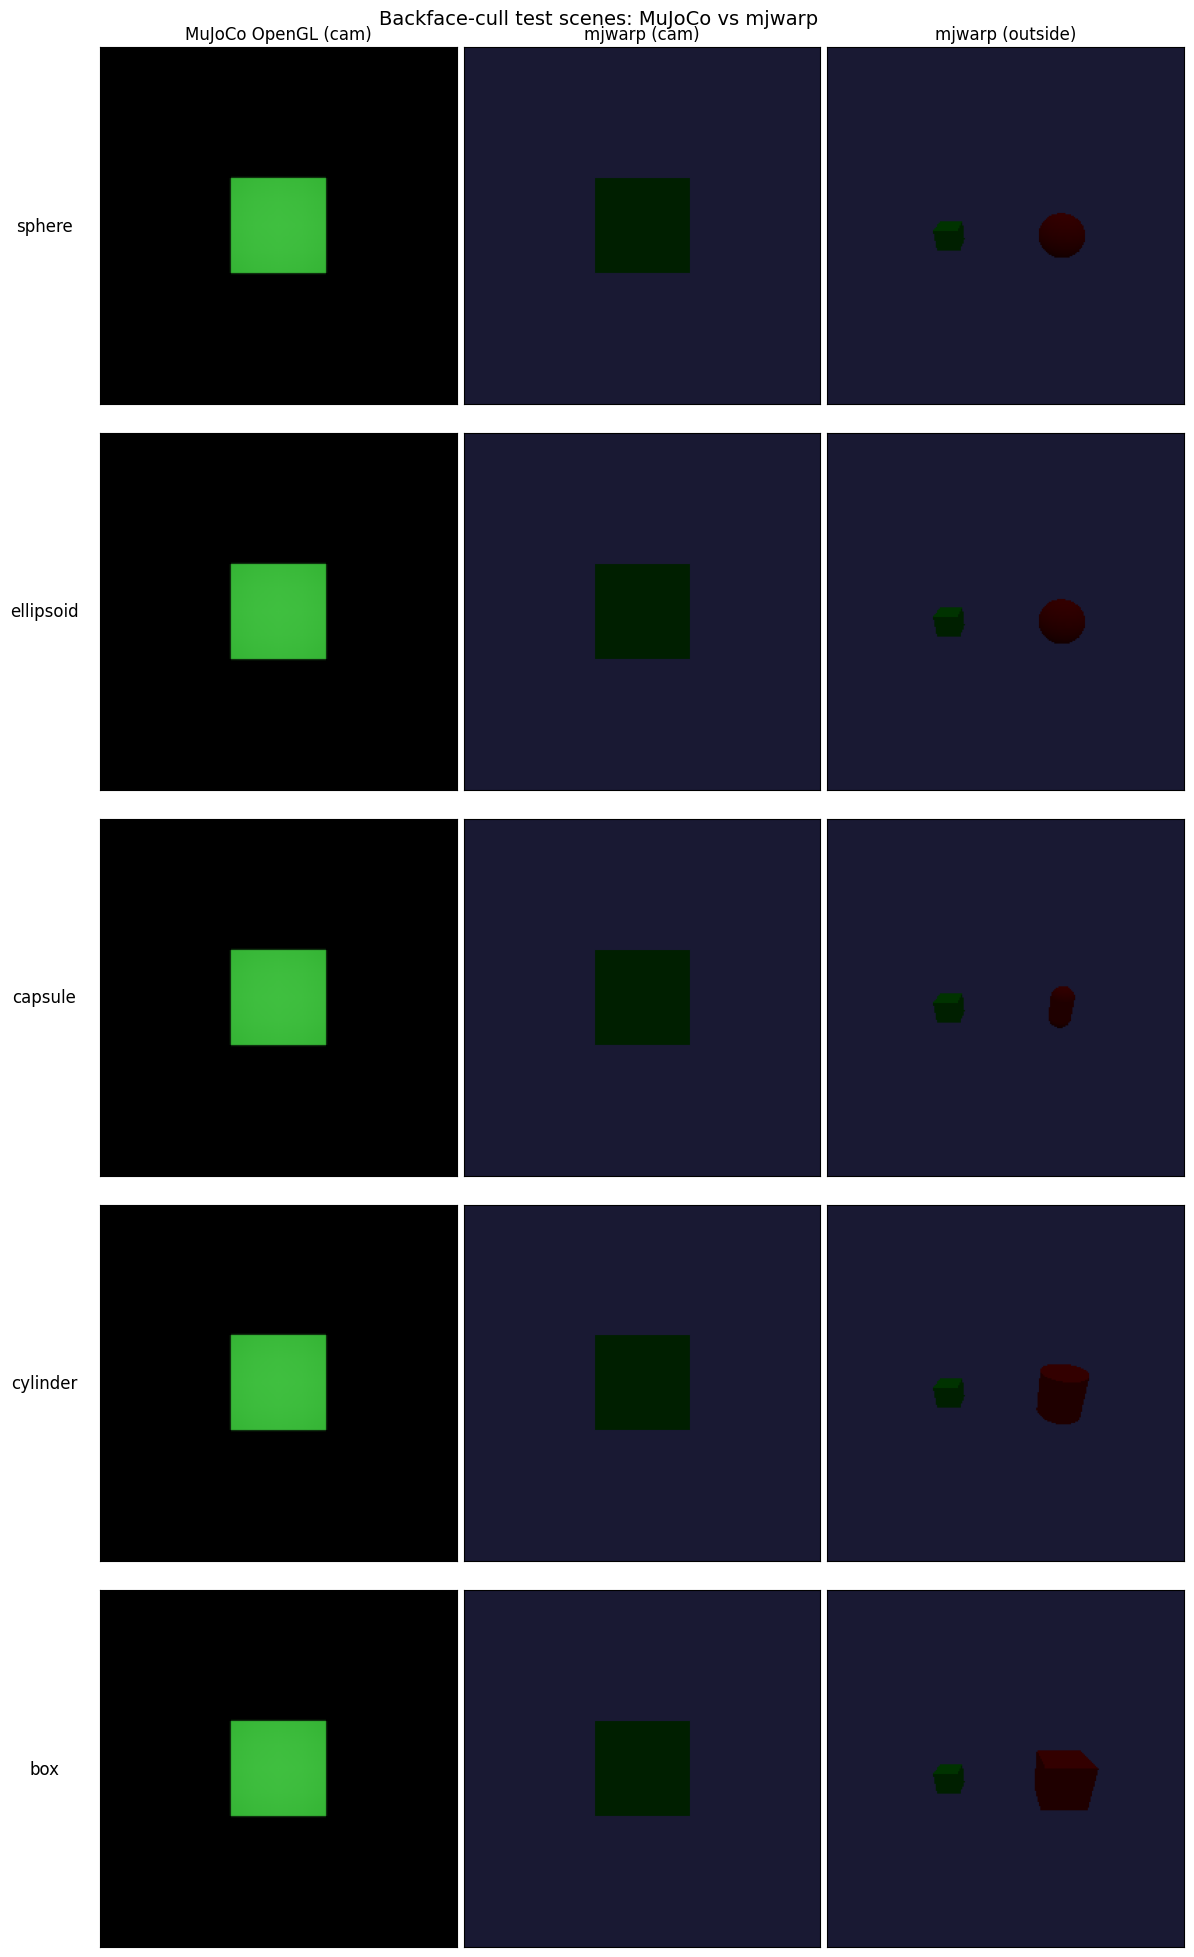

In [4]:
cols = ("mujoco_cam", "warp_cam", "warp_outside")
col_titles = (
    "MuJoCo OpenGL (cam)",
    "mjwarp (cam)",
    "mjwarp (outside)",
)

fig, axes = plt.subplots(
    nrows=len(SHAPES),
    ncols=len(cols),
    figsize=(4 * len(cols), 4 * len(SHAPES)),
)

for i, shape in enumerate(SHAPES):
    for j, key in enumerate(cols):
        ax = axes[i, j]
        img = renders[shape][key]
        if img is None:
            ax.text(
                0.5, 0.5,
                "OpenGL\nunavailable",
                ha="center", va="center",
                transform=ax.transAxes,
                fontsize=11,
                color="0.4",
            )
            ax.set_facecolor("0.95")
        else:
            ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0:
            ax.set_title(col_titles[j], fontsize=12)
        if j == 0:
            ax.set_ylabel(shape, fontsize=12, rotation=0, labelpad=40, va="center")

fig.suptitle("Backface-cull test scenes: MuJoCo vs mjwarp", fontsize=14)
fig.tight_layout()
plt.show()

## Per-pixel difference (optional)

If MuJoCo's OpenGL renderer is available, we can also visualize the absolute per-pixel difference between the reference and mjwarp output for the `cam` view. Tone differences (lighting, gamma) mean these aren't expected to be black; what we care about is that **neither image fills the frame with the enclosure's inner wall**.

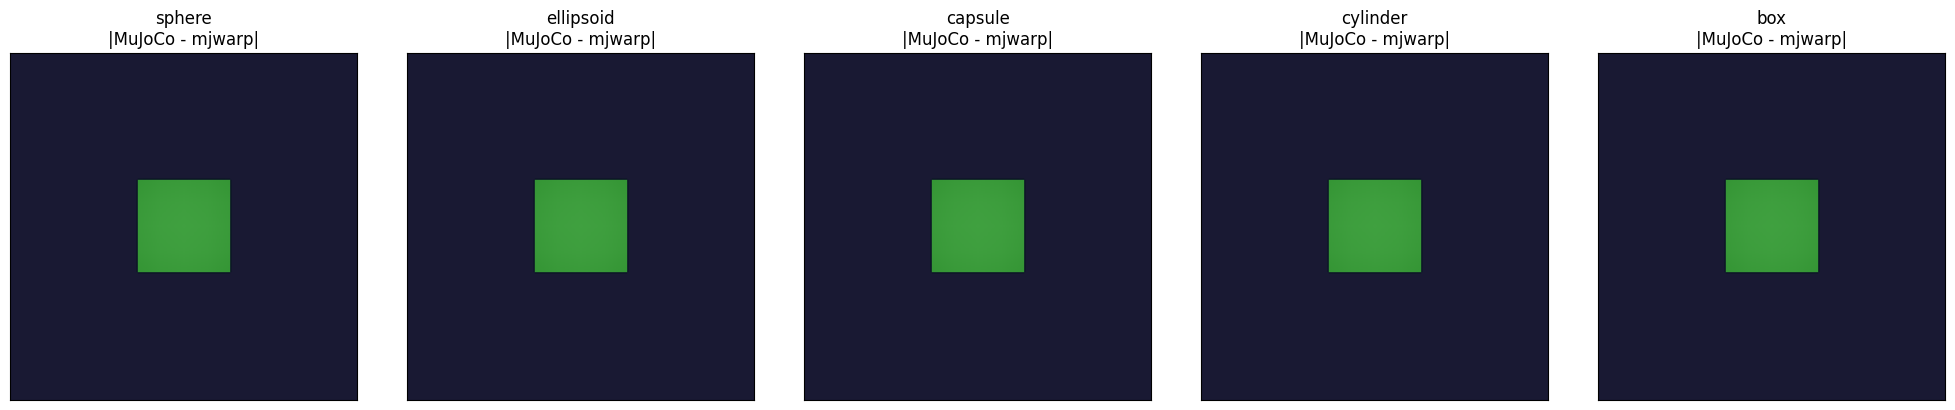

In [5]:
if _HAS_GL:
    fig, axes = plt.subplots(nrows=1, ncols=len(SHAPES), figsize=(4 * len(SHAPES), 4))
    for j, shape in enumerate(SHAPES):
        a = renders[shape]["mujoco_cam"]
        b = renders[shape]["warp_cam"]
        diff = np.abs(a.astype(np.int16) - b.astype(np.int16)).astype(np.uint8)
        axes[j].imshow(diff)
        axes[j].set_xticks([])
        axes[j].set_yticks([])
        axes[j].set_title(f"{shape}\n|MuJoCo - mjwarp|")
    fig.tight_layout()
    plt.show()
else:
    print("Skipping diff: MuJoCo OpenGL renderer was not available.")